In [1]:
import pandas as pd
import numpy as np

# Load with specific parameters for the UCI format
df = pd.read_csv('../data/raw/household_power_consumption.txt', 
                 sep=';', 
                 parse_dates={'dt' : ['Date', 'Time']}, 
                 infer_datetime_format=True, 
                 low_memory=False, 
                 na_values=['?'], 
                 index_col='dt')

# Drop rows where everything is null (common in sensor datasets)
df.dropna(how='all', inplace=True)

# Interpolate missing values
# Linear interpolation is better than 'mean' for time-series as it preserves the slope
df = df.astype('float32').interpolate(method='linear')

C:\Users\Subhrank\AppData\Local\Temp\ipykernel_17264\158372359.py:5: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv('../data/raw/household_power_consumption.txt',
C:\Users\Subhrank\AppData\Local\Temp\ipykernel_17264\158372359.py:5: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv('../data/raw/household_power_consumption.txt',
C:\Users\Subhrank\AppData\Local\Temp\ipykernel_17264\158372359.py:5: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv('../data/raw/household_power_consumption.txt

In [2]:
def add_time_features(df):
    df = df.copy()
    df['hour'] = df.index.hour
    df['day_of_week'] = df.index.dayofweek
    df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
    df['month'] = df.index.month
    return df

df = add_time_features(df)

In [4]:
# 1. Clean column names (removes any accidental trailing spaces)
df.columns = df.columns.str.strip()

# 2. Re-run feature engineering to ensure time columns exist
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['month'] = df.index.month

# 3. Define the aggregation map explicitly
# We'll check if columns exist before aggregating to prevent the KeyError
agg_map = {
    'Global_Active_Power': 'mean',
    'Global_reactive_Power': 'mean',
    'Voltage': 'mean',
    'Global_intensity': 'mean',
    'Sub_metering_1': 'sum',
    'Sub_metering_2': 'sum',
    'Sub_metering_3': 'sum',
    'hour': 'first',
    'day_of_week': 'first',
    'is_weekend': 'first',
    'month': 'first'
}

# Only include columns that actually exist in the dataframe
final_agg = {k: v for k, v in agg_map.items() if k in df.columns}

# 4. Perform the resampling
df_hourly = df.resample('H').agg(final_agg)

# Check the result
print(f"Original shape: {df.shape}")
print(f"Resampled shape: {df_hourly.shape}")
df_hourly.head()

C:\Users\Subhrank\AppData\Local\Temp\ipykernel_17264\1756302045.py:30: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('H').agg(final_agg)


Original shape: (2049280, 11)
Resampled shape: (34589, 9)


,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day_of_week,is_weekend,month
dt,,,,,,,,,
2006-12-16 17:00:00,234.643875,18.099998,0.0,19.0,607.0,17.0,5.0,1.0,12.0
2006-12-16 18:00:00,234.580154,15.600000,0.0,403.0,1012.0,18.0,5.0,1.0,12.0
2006-12-16 19:00:00,233.232498,14.503333,0.0,86.0,1001.0,19.0,5.0,1.0,12.0
2006-12-16 20:00:00,234.071503,13.916667,0.0,0.0,1007.0,20.0,5.0,1.0,12.0
2006-12-16 21:00:00,237.158661,13.046666,0.0,25.0,1033.0,21.0,5.0,1.0,12.0


In [7]:
# 1. Standardize names in the MAIN dataframe first
df.columns = df.columns.str.strip().str.lower()

# 2. Check if 'global_active_power' is now there
print("Columns in df:", df.columns.tolist())

# 3. Redefine the aggregation map with LOWERCASE keys
agg_map = {
    'global_active_power': 'mean',
    'global_reactive_power': 'mean',
    'voltage': 'mean',
    'global_intensity': 'mean',
    'sub_metering_1': 'sum',
    'sub_metering_2': 'sum',
    'sub_metering_3': 'sum',
    'hour': 'first',
    'day_of_week': 'first',
    'is_weekend': 'first',
    'month': 'first'
}

# 4. Perform Resampling
df_hourly = df.resample('H').agg(agg_map)

# 5. Save the fixed version
df_hourly.to_csv('../data/processed/cleaned_hourly_data.csv')

print("Resampling successful. New columns:", df_hourly.columns.tolist())

Columns in df: ['global_active_power', 'global_reactive_power', 'voltage', 'global_intensity', 'sub_metering_1', 'sub_metering_2', 'sub_metering_3', 'hour', 'day_of_week', 'is_weekend', 'month']


C:\Users\Subhrank\AppData\Local\Temp\ipykernel_17264\4138521222.py:23: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('H').agg(agg_map)


Resampling successful. New columns: ['global_active_power', 'global_reactive_power', 'voltage', 'global_intensity', 'sub_metering_1', 'sub_metering_2', 'sub_metering_3', 'hour', 'day_of_week', 'is_weekend', 'month']


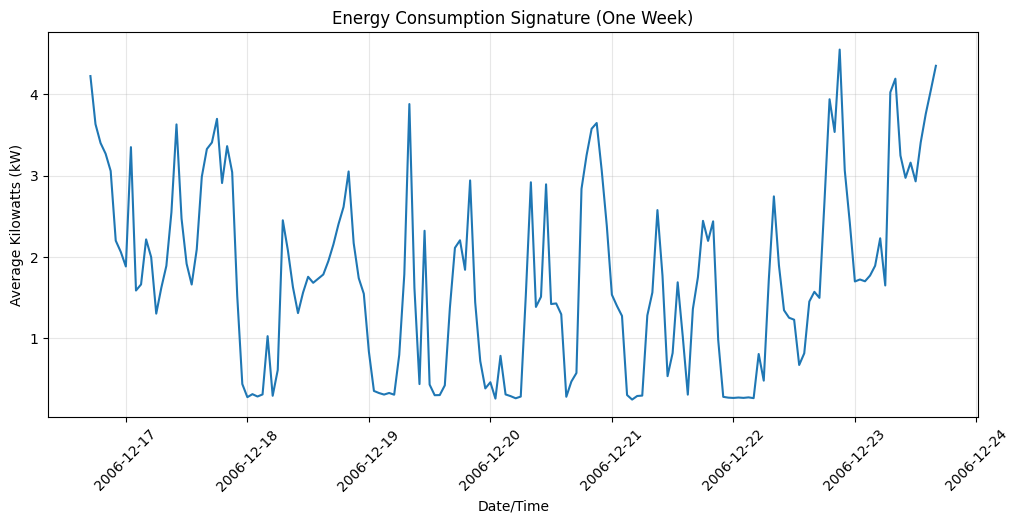

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Standardize all column names to lowercase to avoid casing headaches
df_hourly.columns = [col.lower() for col in df_hourly.columns]

# 2. Identify the target column (usually 'global_active_power')
target_col = 'global_active_power'

if target_col in df_hourly.columns:
    plt.figure(figsize=(12, 5))
    
    # Grab the first week (24 hours * 7 days = 168 rows)
    plot_data = df_hourly.head(168)
    
    # Simple plot: x is the index (time), y is our power column
    sns.lineplot(data=plot_data, x=plot_data.index, y=target_col)
    
    plt.title('Energy Consumption Signature (One Week)')
    plt.ylabel('Average Kilowatts (kW)')
    plt.xlabel('Date/Time')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print(f"Error: Could not find {target_col}. Available columns are: {list(df_hourly.columns)}")